In [80]:
from jax_signatures.signature import * 
from jax_signatures.exact_representations import * 
from jax_signatures.ode_solver import * 
from schemes import * 
from trajectories import *
from utils import *

from matplotlib.ticker import FuncFormatter
import time 

In [81]:
lambd = jnp.array([1, 1])
U = simulate_antithetic(10000000, 1).squeeze(-1) * np.sqrt(0.5 * lambd[1])
mean, _, lower, upper = monte_carlo(np.exp(1j * U**4 / 24))

In [82]:
@jax.jit
def ode_fun(psi: Tensor, args: dict) -> Tensor:
    return psi.proj(1) + psi.proj(22) * 0.5 + shuffle_pow(psi.proj(2), 2, args["shuffle_table"]) * 0.5

## I. Incidence of the discretization step $h = \frac{T}{n}$

In [16]:
M, d = 12, 2 
init = from_word(2222, M, d) * 1j
shuffle_table = get_shuffle_table(M, d)
args = {"shuffle_table" : shuffle_table, "lambd" : lambd}

In [17]:
T = 10 
n_values = np.linspace(100, 1000, 10, dtype=int) 
n_values = np.linspace(100, 500, 10, dtype=int) 
values_euler, values_RK4, values_PECE = [], [], []
for n in tqdm(n_values) : 
    t_grid = np.linspace(0, T, n+1) 
    values_euler.append(np.exp(ode_solver(fun=ode_fun, step_fun=step_fun_semi_int_euler, t_grid=t_grid, init=init, args=args)[0]))
    values_RK4.append(np.exp(ode_solver(fun=ode_fun, step_fun=step_fun_semi_int_RK4, t_grid=t_grid, init=init, args=args)[0]))
    values_PECE.append(np.exp(ode_solver(fun=ode_fun, step_fun=step_fun_semi_int_PECE, t_grid=t_grid, init=init, args=args)[0]))

100%|███████████████████████████████████████████| 10/10 [05:09<00:00, 30.91s/it]


In [18]:
values_euler = np.array(values_euler)
values_RK4 = np.array(values_RK4)
values_PECE = np.array(values_PECE)

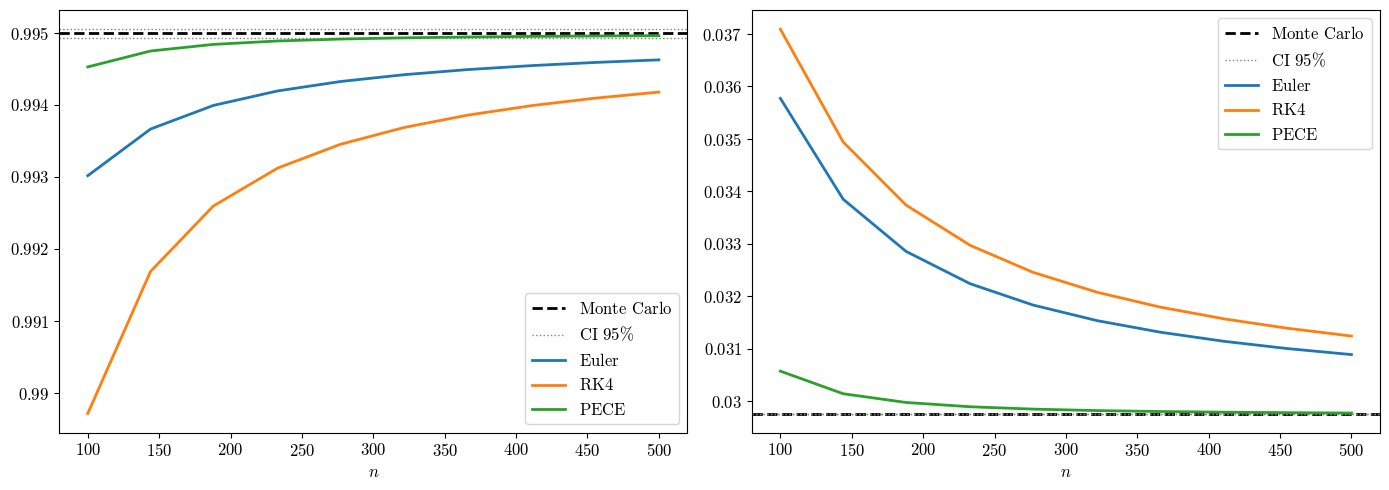

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].axhline(mean.real, lw=2, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
ax[0].axhline(lower.real, lw=1, color="gray", linestyle=":", label=r"$\text{CI }95\%$")
ax[0].axhline(upper.real, lw=1, color="gray", linestyle=":")
ax[0].plot(n_values, values_euler.real, lw=2, label=r"$\text{Euler}$")
ax[0].plot(n_values, values_RK4.real, lw=2, label=r"$\text{RK4}$")
ax[0].plot(n_values, values_PECE.real, lw=2, label=r"$\text{PECE}$")

ax[1].axhline(mean.imag, lw=2, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
ax[1].axhline(lower.imag, lw=1, color="gray", linestyle=":", label=r"$\text{CI }95\%$")
ax[1].axhline(upper.imag, lw=1, color="gray", linestyle=":")
ax[1].plot(n_values, values_euler.imag, lw=2, label=r"$\text{Euler}$")
ax[1].plot(n_values, values_RK4.imag, lw=2, label=r"$\text{RK4}$")
ax[1].plot(n_values, values_PECE.imag, lw=2, label=r"$\text{PECE}$")

for i in range(2) : 
    ax[i].set_xlabel(r"$n$", fontsize=12)
    ax[i].legend(fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 

plt.tight_layout()
plt.show()

## II. Incidence of the truncation order $M$

In [83]:
T, n = 10, 300
t_grid = np.linspace(0, T, n+1) 

M_values = np.arange(3, 13) 
values_euler, values_RK4, values_PECE = [], [], []
for M in tqdm(M_values) : 
    init = from_word(2222, M, d) * 1j
    shuffle_table = get_shuffle_table(M, d)
    args = {"shuffle_table" : shuffle_table, "lambd" : lambd}
    values_euler.append(np.exp(ode_solver(fun=ode_fun, step_fun=step_fun_semi_int_euler, t_grid=t_grid, init=init, args=args)[0]))
    values_RK4.append(np.exp(ode_solver(fun=ode_fun, step_fun=step_fun_semi_int_RK4, t_grid=t_grid, init=init, args=args)[0]))
    values_PECE.append(np.exp(ode_solver(fun=ode_fun, step_fun=step_fun_semi_int_PECE, t_grid=t_grid, init=init, args=args)[0]))

100%|███████████████████████████████████████████| 10/10 [01:18<00:00,  7.84s/it]


In [84]:
values_euler = np.array(values_euler)
values_RK4 = np.array(values_RK4)
values_PECE = np.array(values_PECE)

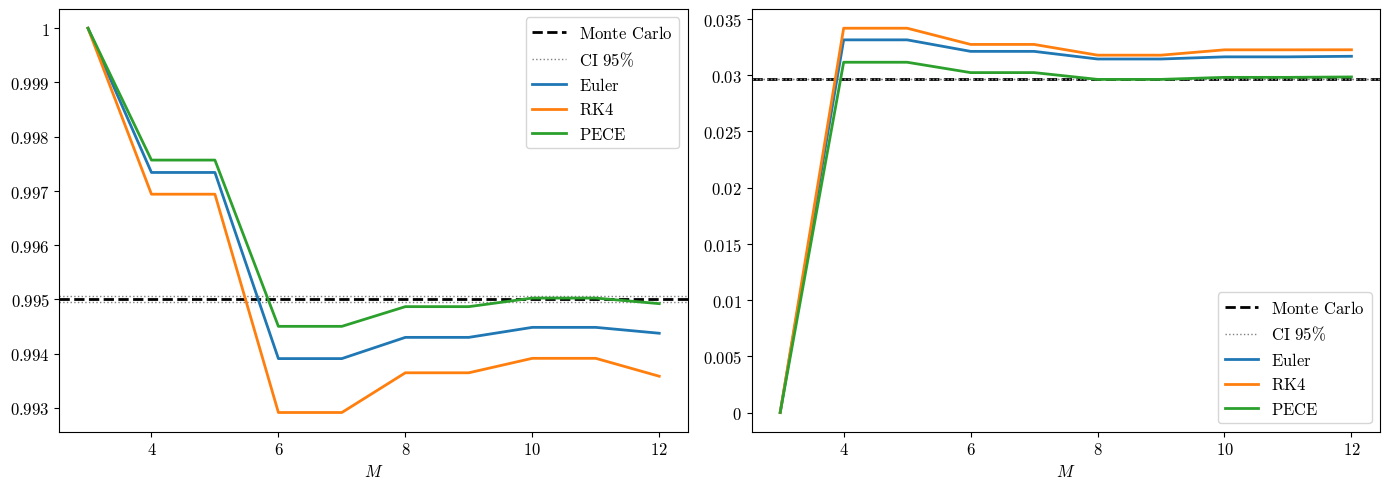

In [85]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].axhline(mean.real, lw=2, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
ax[0].axhline(lower.real, lw=1, color="gray", linestyle=":", label=r"$\text{CI }95\%$")
ax[0].axhline(upper.real, lw=1, color="gray", linestyle=":")
ax[0].plot(M_values, values_euler.real, lw=2, label=r"$\text{Euler}$")
ax[0].plot(M_values, values_RK4.real, lw=2, label=r"$\text{RK4}$")
ax[0].plot(M_values, values_PECE.real, lw=2, label=r"$\text{PECE}$")

ax[1].axhline(mean.imag, lw=2, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
ax[1].axhline(lower.imag, lw=1, color="gray", linestyle=":", label=r"$\text{CI }95\%$")
ax[1].axhline(upper.imag, lw=1, color="gray", linestyle=":")
ax[1].plot(M_values, values_euler.imag, lw=2, label=r"$\text{Euler}$")
ax[1].plot(M_values, values_RK4.imag, lw=2, label=r"$\text{RK4}$")
ax[1].plot(M_values, values_PECE.imag, lw=2, label=r"$\text{PECE}$")

for i in range(2) : 
    ax[i].set_xlabel(r"$M$", fontsize=12)
    ax[i].legend(fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 

plt.tight_layout()
plt.show()

## II. Illustration of the convergence when $T\to\infty$ for various $M$

In [61]:
T, n = 10, 300
t_grid = np.linspace(0, T, n+1) 

M_values = np.arange(4, 13) 
values_euler, values_RK4, values_PECE = [], [], []
for M in tqdm(M_values) : 
    init = from_word(2222, M, d) * 1j
    shuffle_table = get_shuffle_table(M, d)
    args = {"shuffle_table" : shuffle_table, "lambd" : lambd}
    values_euler.append(np.exp(ode_solver_grid(fun=ode_fun, step_fun=step_fun_semi_int_euler, t_grid=t_grid, init=init, args=args)[0]))
    values_RK4.append(np.exp(ode_solver_grid(fun=ode_fun, step_fun=step_fun_semi_int_RK4, t_grid=t_grid, init=init, args=args)[0]))
    values_PECE.append(np.exp(ode_solver_grid(fun=ode_fun, step_fun=step_fun_semi_int_PECE, t_grid=t_grid, init=init, args=args)[0]))

100%|█████████████████████████████████████████████| 9/9 [00:57<00:00,  6.36s/it]


In [62]:
values_euler = np.array(values_euler)
values_RK4 = np.array(values_RK4)
values_PECE = np.array(values_PECE)
values = np.stack([values_euler, values_RK4, values_PECE], axis=-1)

In [63]:
values.shape

(9, 301, 3)

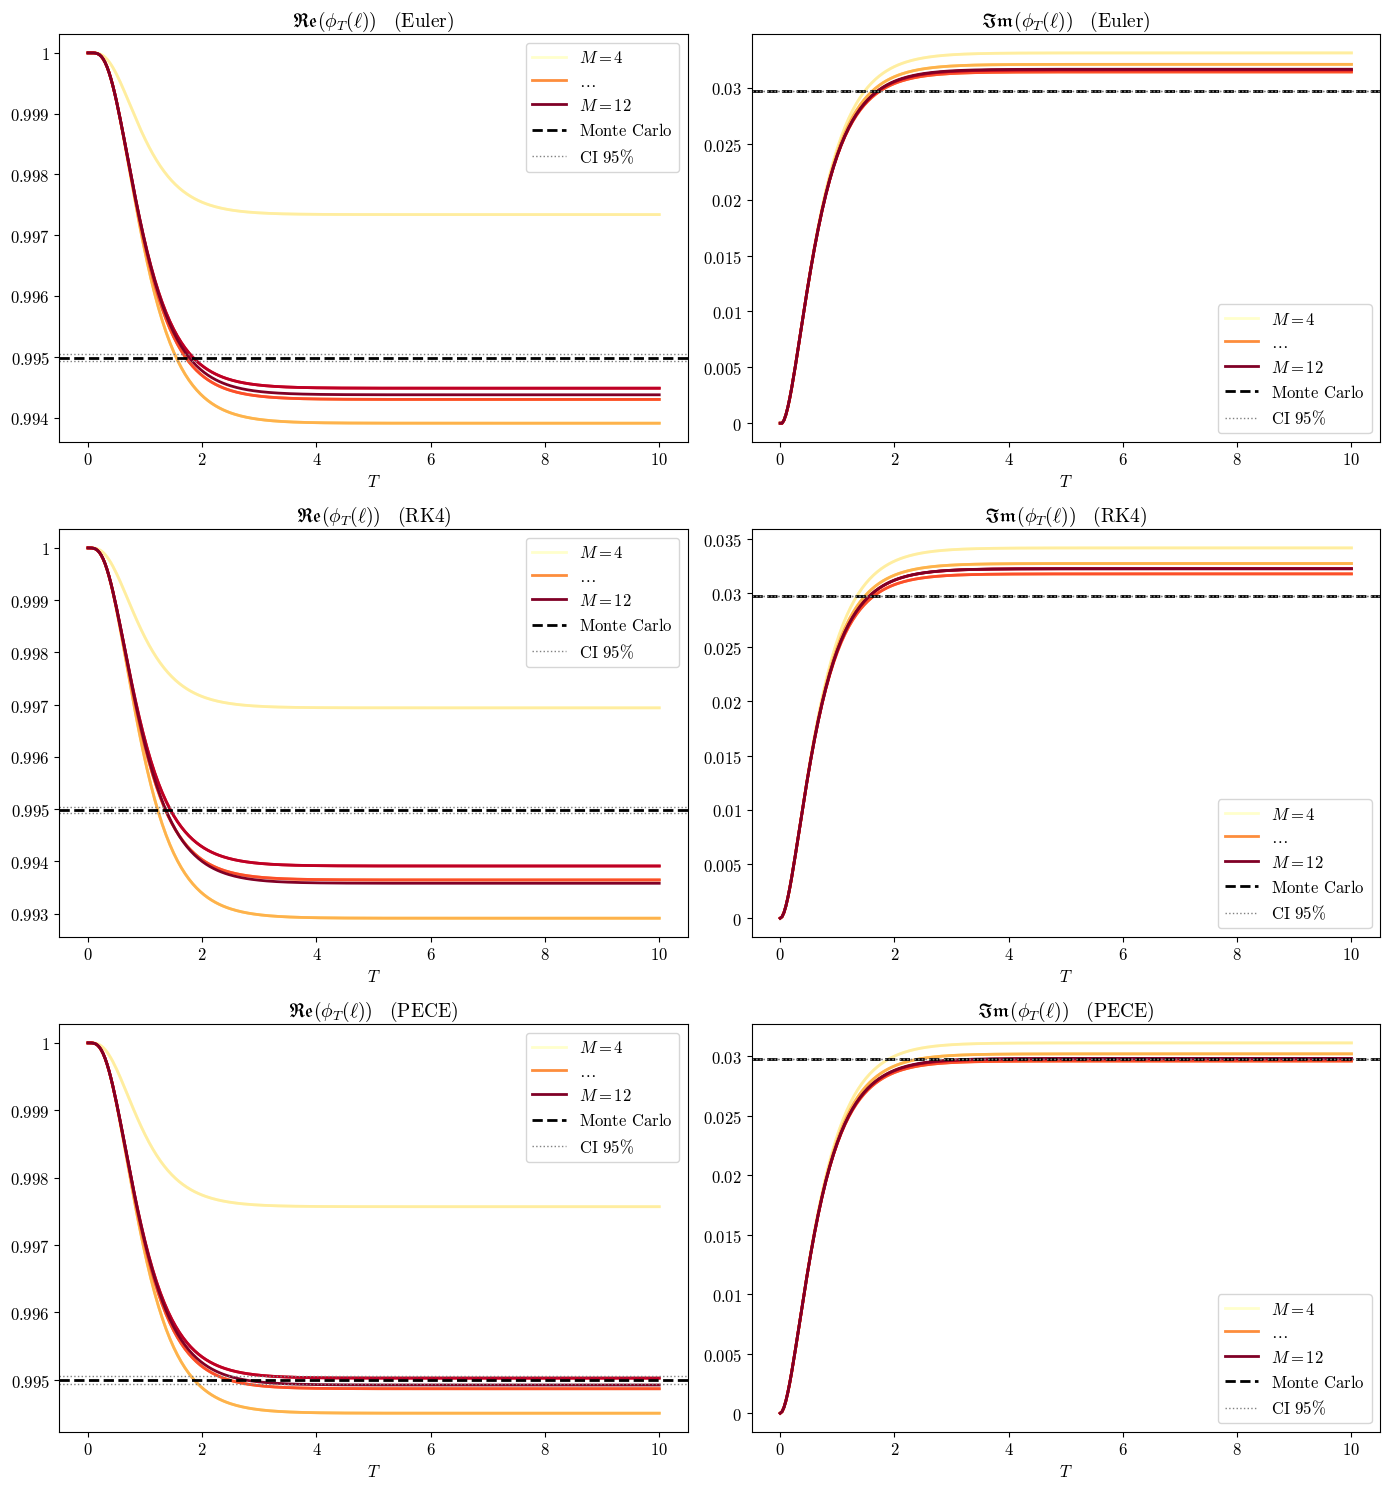

In [79]:
cmap = plt.get_cmap("YlOrRd", len(M_values))
norm = mcolors.Normalize(vmin=M_values.min(), vmax=M_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, ax = plt.subplots(3, 2, figsize=(14, 15))
ax = ax.flatten()
for j in range(3) :
    for i, M in enumerate(M_values) : 
        color = cmap(norm(M))
        if i == 0 or i == len(M_values)-1 : 
            ax[2*j].plot(t_grid, values[i, :, j].real, lw=2, color=color, label=fr"$M={M}$")
            ax[2*j+1].plot(t_grid, values[i, :, j].imag, lw=2, color=color, label=fr"$M={M}$")
        elif i == len(M_values)//2 : 
            ax[2*j].plot(t_grid, values[i, :, j].real, lw=2, color=color, label=fr"$\ldots$")
            ax[2*j+1].plot(t_grid, values[i, :, j].imag, lw=2, color=color, label=fr"$\ldots$")
        else : 
            ax[2*j].plot(t_grid, values[i, :, j].real, lw=2, color=color)
            ax[2*j+1].plot(t_grid, values[i, :, j].imag, lw=2, color=color)

    ax[2*j].axhline(mean.real, lw=2, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
    ax[2*j].axhline(lower.real, lw=1, color="gray", linestyle=":", label=r"$\text{CI }95\%$")
    ax[2*j].axhline(upper.real, lw=1, color="gray", linestyle=":")

    ax[2*j+1].axhline(mean.imag, lw=2, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
    ax[2*j+1].axhline(lower.imag, lw=1, color="gray", linestyle=":", label=r"$\text{CI }95\%$")
    ax[2*j+1].axhline(upper.imag, lw=1, color="gray", linestyle=":")

for i in range(6) : 
    ax[i].set_xlabel(r"$T$", fontsize=12)
    ax[i].legend(fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 

ax[0].set_title(r"$\mathfrak{Re}(\phi_T(\ell)) \quad \text{(Euler)}$", fontsize=14)
ax[1].set_title(r"$\mathfrak{Im}(\phi_T(\ell)) \quad \text{(Euler)}$", fontsize=14)
ax[2].set_title(r"$\mathfrak{Re}(\phi_T(\ell)) \quad \text{(RK4)}$", fontsize=14)
ax[3].set_title(r"$\mathfrak{Im}(\phi_T(\ell)) \quad \text{(RK4)}$", fontsize=14)
ax[4].set_title(r"$\mathfrak{Re}(\phi_T(\ell)) \quad \text{(PECE)}$", fontsize=14)
ax[5].set_title(r"$\mathfrak{Im}(\phi_T(\ell)) \quad \text{(PECE)}$", fontsize=14)

plt.tight_layout()
plt.show()